In [1]:
!pip install langchain langgraph langchain-openai langchain-core langchain-community langchain-experimental fpdf pdfplumber

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.7 MB/s eta 0:00:00
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=6339451b3d737089892200a73768b3a2f9b09dc0e715a78d644c1874c681ce13
  Stored in directory: /ro

In [2]:
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import AIMessage
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.prompts import PromptTemplate
from langchain_core.tools import tool
from langchain_community.agent_toolkits import FileManagementToolkit
from langchain_experimental.tools.python.tool import PythonAstREPLTool
from pydantic import BaseModel, Field
from fpdf import FPDF
import random
import pdfplumber
import os
import requests
import warnings

warnings.filterwarnings("ignore")

/tmp/ipykernel_5909/3254521282.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
/tmp/ipykernel_5909/3254521282.py:13: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.tools.python.tool import PythonAstREPLTool


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


- [TAVILY](https://www.tavily.com/)는 LLM 모델의 웹서치 기능을 붙여주는 대표적인 API 서비스

In [6]:
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get('ㅇ')
os.environ["TAVILY_API_KEY"] = userdata.get('ㅇ')


In [7]:
# 그래프 상태 정의

class State(TypedDict):
    query : Annotated[str, "User Question"]
    answer : Annotated[str, "LLM response"]
    messages : Annotated[list, add_messages]
    tool_call : Annotated[dict, "Tool Call Result"]

In [8]:
# LLM 정의
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o",
                             temperature=0)


In [9]:
@tool
def read_pdf(file_path: str):
    """
    PDF 파일에서 텍스트를 추출하는 도구입니다.
    표 형식 또는 일반 텍스트가 포함된 PDF를 읽고 문자열로 반환합니다.

    file_path 예시: './report.pdf'
    """
    try:
        text = ""
        with pdfplumber.open(file_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
        return text.strip() if text.strip() else "❌ PDF에서 텍스트를 추출할 수 없습니다."
    except Exception as e:
        return f"❌ PDF 읽기 오류: {str(e)}"

In [10]:
@tool
def write_pdf(content: str, filename: str = "output.pdf", summary: bool =True):
    """
    텍스트를 PDF 파일로 저장하는 도구입니다.
    PDF형태의 문서로 만들어야할 때 이 도구를 사용하세요.
    """

    if summary:
        prompt = PromptTemplate.from_template("""
                당신은 보고서를 작성하는 어시스턴트입니다. 당신에겐 문서 모음이 제공되고 이를 잘 분석하여 보고서를 작성하여야 합니다.
                아래의 content는 문서 모음입니다. 문서의 제목, 본문을 잘 판단하고 정리하여 요약합니다.
                항상 구조화된 출력을 제공하세요.
                항상 마지막엔 인사이트도 첨부합니다.

                content : {content}
                """)

        chain = prompt | llm

        content = chain.invoke({"content":content}).content

    else:
        pass

    font_url = "https://github.com/google/fonts/raw/main/ofl/notosanskr/NotoSansKR%5Bwght%5D.ttf"
    font_path = "./fonts/NotoSansKR.ttf"

    try:
        os.mkdir("./fonts/")
        response = requests.get(font_url)
        with open(font_path, "wb") as f:
            f.write(response.content)
    except:
        pass

    pdf = FPDF()
    pdf.add_page()
    pdf.set_auto_page_break(auto=True, margin=15)

    font_path = "./fonts/NotoSansKR.ttf"  # <-- 여기에 실제 폰트 파일이 있어야 함

    try:
        pdf.add_font("NotoSans", "", font_path, uni=True)
        pdf.set_font("NotoSans", size=12)
    except:
        raise ValueError("한글 폰트를 등록할 수 없습니다.")

    for line in content.split("\n"):
        pdf.multi_cell(0, 10, line)
    pdf.output(f"./{filename}")

    return f"{filename} 저장 완료"

In [11]:
# 툴 정의
# TavilySearchResults : 웹 검색 도구
# PythonAstREPLTool : 파이썬 코드 실행 도구
# write_pdf : pdf 생성 도구
# read_pdf : pdf 읽기 도구
# file_delete : 파일 삭제 도구
# list_directory : 파일 목록 읽기 도구

tools = [TavilySearchResults(max_results=10), PythonAstREPLTool(), write_pdf, read_pdf, *FileManagementToolkit(
                                                                            selected_tools=["file_delete","list_directory"]).get_tools()]
search_tool, code_tool, write_tool, read_tool, delete_tool, listdir_tool= tools

In [12]:
# PDF 쓰기 도구 예시

write_tool.invoke({"content":"안녕하세요! \nLanggraph 예제코드입니다.", "filename":"Langgraph_report.pdf", "summary":False})

'Langgraph_report.pdf 저장 완료'

In [13]:
# PDF 읽기 도구 예시

print("\n\n", read_tool.invoke("/content/Langgraph_report.pdf"))



 안녕하세요!
Langgraph 예제코드입니다.


In [14]:
# 파일 목록 도구 예시

print(listdir_tool.invoke(input=""))

.config
drive
titanic (1).csv
athlete_events.csv
Langgraph_report.pdf
fonts
sample_data


In [15]:
# 삭제 도구 예시

delete_tool.invoke("Langgraph_report.pdf")

'File deleted successfully: Langgraph_report.pdf.'

In [16]:
# LLM에게 도구 할당

llm_with_tools = llm.bind_tools(tools)

In [17]:
# 전체 메시지 중 마지막 메시지를 제외하고 최대 8개까지 단기 기억(history)으로 추출

def shorterm_memory(state:State):

    if len(state["messages"]) > 8:
        history = state["messages"][-8:-1]
    elif len(state["messages"]) == 1:
        history = ""
    else:
        history = state["messages"][:-1]

    return history

In [18]:
class HistoryChecker(BaseModel):
    """
    이전의 대화 기록을 참고하여 질문에 대해 답변할 수 있는지 판단합니다.
    답변할 수 있다면 "yes", 답변할 수 없다면 "no"를 반환합니다.
    """

    yes_no : Literal["yes", "no"] = Field(..., description="""Use your previous conversation history to determine if you can answer your questions.
    Return "yes" if you can answer, "no" if you can't answer.""")

In [19]:
# 히스토리 기반 답변 분기를 위한 함수 설정

def history_check(state:State):

    prompt = PromptTemplate.from_template("""

                이전의 대화 기록을 참고하여 질문에 대해 답변할 수 있는지 판단합니다.
                답변할 수 있다면 "yes", 답변할 수 없다면 "no"를 반환합니다.

                대화 기록 : {history}

                질문 : {query}

                """)

    chain = prompt | history_checker

    history = shorterm_memory(state)

    result = chain.invoke({"history":history,
                            "query":state["query"]})

    return result.yes_no

In [20]:
# LLM의 응답을 HistoryChecker 클래스 구조에 맞춰 파싱하도록 설정

history_checker = llm.with_structured_output(HistoryChecker)

In [21]:
# 기억 기반 답변 노드

def memory_chat(state:State):

    prompt = PromptTemplate.from_template("""

                이전의 대화 기록을 참고하여 질문에 대해 답변하세요.
                아래 대화 기록을 첨부합니다.
                대화 기록을 통해 답변이 어렵다면 내부 지식을 참조하세요.

                대화 기록 : {history}

                질문 : {query}

                """)


    chain = prompt | llm

    history = shorterm_memory(state)

    result = chain.invoke({"history":history,
                           "query":state["query"]})

    if len(state["tool_call"]) == 0:
        return {"answer":result.content,
                "messages":result,
                "tool_call":"사용된 기록 없음."}
    else:
        return {"answer":result.content,
                "messages":result}

In [22]:
# 기억 기반 답변 분기 노드

def history_node(state:State):
    if len(state["messages"]) == 1:
        return {"answer":"답변 없음",
                "tool_call":"사용된 도구 없음"}
    else:
        return state

In [23]:
# 도구 선택 노드

def select(
    state: State,
):

    prompt = PromptTemplate.from_template("""

                이전의 대화 기록을 참고하여 질문에 대해 답변하세요.
                아래 대화 기록을 첨부합니다.
                이전의 대화가 다음에 어떤 도구를 사용해야하는지 힌트가 될 수 있습니다. 꼭 참조하세요.
                도구의 변화가 큰 결과를 가져올 수 있습니다.
                들어온 메시지, 정답, 이전 기록을 모두 분석하여 가장 적절한 도구를 선택하세요.

                대화 기록 : {history}

                최근 사용한 도구 : {tool_name}

                정답 : {answer}

                질문 : {query}

                """)

    chain = prompt | llm_with_tools

    history = shorterm_memory(state)

    result = chain.invoke({"history" : history,
                           "tool_name" : state["tool_call"],
                            "answer": state["answer"],
                            "query": state["query"]})

    if hasattr(result, "tool_calls") and len(result.tool_calls) > 0:
        tool_calls = result.tool_calls

        return {"messages": result,
                "tool_call":tool_calls}
    else:
        return {"messages":AIMessage(content=f"""도구를 선택하지 못했습니다. 적절한 도구를 재선택하세요.
                                        """),
                                    "tool_call":"선택된 도구 없음"}



In [24]:
# 도구 실행 노드

tool_node = ToolNode(tools)

In [25]:
class AnswerChecker(BaseModel):
    """
    정답 분류기입니다.

    정답이 질문을 해결했는지 여부를 판단합니다.
    질문을 해결하지 못했을 시 해결될 때까지 도구를 이용합니다.

    질문을 해결했다면 "end", 해결하지 못했다면 "tool"을 반환합니다.
    """


    end : Literal["end", "tool"] = Field(..., description="""You are the answer sorter.

                                                                Determine if the correct answer has solved the question.
                                                                If the question is not resolved, use the tool until it is resolved.

                                                                Return "end" if you solved the question, or "tool" if you didn't.""")

In [26]:
# LLM의 응답을 AnswerChecker 클래스 구조에 맞춰 파싱하도록 설정

answer_checker = llm.with_structured_output(AnswerChecker)

In [27]:
# 답변 확인 노드

def response(state:State):

    return {"answer":state["messages"][-1]}

In [28]:
# 답변 완성 판단 분기 함수

def answer_check(state:State):

    prompt = PromptTemplate.from_template("""
    당신은 정답 분류기 어시스턴트입니다.

    정답이 질문을 해결하였는지 여부를 판단합니다.
    질문을 해결하지 못했다면 도구를 이용합니다.

    질문을 해결하였다면 "end", 아니라면 "tool"을 반환합니다.

    기존 History도 참고하여 답변하세요.

    History : {history}

    정답 : {answer}

    질문 : {query}
    """)

    chain = prompt | answer_checker

    history = shorterm_memory(state)

    result = chain.invoke({"history" : history,
                            "answer": state["answer"],
                            "query": state["query"]})

    return result.end

In [29]:
# 그래프 정의

graph_builder = StateGraph(State)

In [30]:
# 노드 및 엣지 정의

graph_builder.add_node("history_node", history_node)
graph_builder.add_node("memory_chat", memory_chat)
graph_builder.add_node("select", select)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("response", response)


graph_builder.add_edge(START, "history_node")
graph_builder.add_conditional_edges("history_node",
                            history_check,
                            {"yes":"memory_chat",
                             "no":"select"})
graph_builder.add_edge("select", "tools")
graph_builder.add_edge("tools", "response")
graph_builder.add_edge("memory_chat", "response")
graph_builder.add_conditional_edges("response",
                                    answer_check,
                                    {"end":END,
                                    "tool":"select"});

In [31]:
# 메모리 설정 및 그래프 컴파일

memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

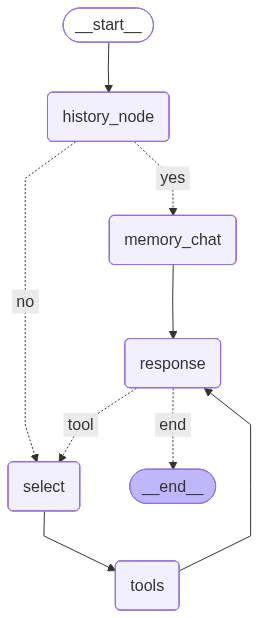

In [32]:
# 그래프 시각화
# 가끔 "ReadTimeout: HTTPSConnectionPool(host='mermaid.ink', port=443): Read timed out. (read timeout=10)"라는 에러가 발생
# 시간 초과로 그래프 생성에 실패했다는 메시지일뿐 기능과는 관계없으니 진행해도 괜찮습니다.

graph

In [33]:
# config 재생성 노드, config의 재사용은 고려되지 않음. 재사용한다면 변수에 할당하여 사용할 것

def reset_config(limit=20):

    thread_id=random.randint(1,999999)

    config = RunnableConfig(recursion_limit=limit, configurable={"thread_id": thread_id})

    return config

In [34]:
# 출력 함수 정의
# mode = "values" : 상태의 키, 값의 형태로 반환
# mode = "updates" : 업데이트되는 값만 반환

def streaming(query, config, mode="values"):

    result = graph.stream({"messages":("user", query),
                         "query":query}, config=config, stream_mode=mode)

    if mode == "values":
        for step in result:
            for k, v in step.items():
                if k == "messages":
                    v[-1].pretty_print()
    elif mode == "updates":
        for step in result:
            for k,v in step.items():
                print(f"\n\n=== {k} ===\n\n")
                print(v)

    return

In [35]:
config = reset_config()

query = "1+1은 뭔가요?"

streaming(query, config)

================================ Human Message =================================

1+1은 뭔가요?
================================ Human Message =================================

1+1은 뭔가요?
================================== Ai Message ==================================

1+1은 2입니다.
================================== Ai Message ==================================

1+1은 2입니다.


In [37]:
config = reset_config()

query = "현대자동차라는 회사에 대해 조사해주세요. 잘 정리된 보고서를 제공해주십시오. pdf 포멧의 파일로 받기를 희망합니다."

streaming(query, config)

================================ Human Message =================================

현대자동차라는 회사에 대해 조사해주세요. 잘 정리된 보고서를 제공해주십시오. pdf 포멧의 파일로 받기를 희망합니다.
================================ Human Message =================================

현대자동차라는 회사에 대해 조사해주세요. 잘 정리된 보고서를 제공해주십시오. pdf 포멧의 파일로 받기를 희망합니다.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_G9KKvWfKBsG38G6zh4W7F3Or)
 Call ID: call_G9KKvWfKBsG38G6zh4W7F3Or
  Args:
    query: Hyundai Motor Company overview 2023
================================= Tool Message =================================
Name: tavily_search_results_json

HTTPError('401 Client Error: Unauthorized for url: https://api.tavily.com/search')
================================= Tool Message =================================
Name: tavily_search_results_json

HTTPError('401 Client Error: Unauthorized for url: https://api.tavily.com/search')
================================== Ai Message =============

In [38]:
query = "현대자동차의 경쟁사에 대한 정보도 정리된 보고서를 작성해주세요."

streaming(query, config)

================================ Human Message =================================

현대자동차의 경쟁사에 대한 정보도 정리된 보고서를 작성해주세요.
================================ Human Message =================================

현대자동차의 경쟁사에 대한 정보도 정리된 보고서를 작성해주세요.
================================== Ai Message ==================================
Tool Calls:
  write_pdf (call_BilrVYtFhfCk27774646CB3c)
 Call ID: call_BilrVYtFhfCk27774646CB3c
  Args:
    content: 현대자동차의 주요 경쟁사는 글로벌 자동차 시장에서 다양한 차종을 생산하고 있는 기업들입니다. 이들 경쟁사는 기술 혁신, 친환경 차량 개발, 글로벌 시장 점유율 확대 등 여러 측면에서 현대자동차와 경쟁하고 있습니다.

### 주요 경쟁사

1. **도요타 자동차 (Toyota Motor Corporation)**
   - **본사 위치**: 일본 아이치현
   - **주요 제품**: 승용차, 하이브리드차, 전기차, 수소차
   - **특징**: 도요타는 하이브리드 기술의 선두주자로, 프리우스 모델을 통해 친환경 차량 시장을 선도하고 있습니다. 또한, 수소차 개발에도 적극적입니다.

2. **폭스바겐 그룹 (Volkswagen Group)**
   - **본사 위치**: 독일 볼프스부르크
   - **주요 제품**: 승용차, 전기차, 상용차
   - **특징**: 폭스바겐은 전기차 플랫폼 MEB를 기반으로 다양한 전기차 모델을 출시하고 있으며, 2025년까지 전기차 판매 비중을 크게 늘릴 계획입니다.

3. **제너럴 모터스 (General Motors)**
   - **본사 위치**: 미국 디트로이트

In [39]:
#config = reset_config()

#query = "현재 폴더의 pdf로 이루어진 파일 모두 삭제해줘"

#streaming(query, config)

In [40]:
config = reset_config()

code = """
아래 코드 실행시켜주세요.

```python

result = 0

for i in range(20):
    print(f"{i+1}번째 출력: ", i+1)
    result += i

print("최종 결과: ", result)

```
"""

streaming(code, config)

================================ Human Message =================================


아래 코드 실행시켜주세요.

```python

result = 0

for i in range(20):
    print(f"{i+1}번째 출력: ", i+1)
    result += i

print("최종 결과: ", result)

```

================================ Human Message =================================


아래 코드 실행시켜주세요.

```python

result = 0

for i in range(20):
    print(f"{i+1}번째 출력: ", i+1)
    result += i

print("최종 결과: ", result)

```

================================== Ai Message ==================================

이 코드는 Python으로 작성된 간단한 반복문입니다. 코드를 실행하면 다음과 같은 일이 발생합니다:

1. `result`라는 변수가 0으로 초기화됩니다.
2. `for` 루프는 0부터 19까지의 숫자(i)를 반복합니다.
3. 각 반복에서 `i+1`을 출력하고, `result`에 `i`를 더합니다.
4. 루프가 끝나면 `result`의 최종 값을 출력합니다.

코드를 실행하면 다음과 같은 출력이 예상됩니다:

```
1번째 출력:  1
2번째 출력:  2
3번째 출력:  3
...
20번째 출력:  20
최종 결과:  190
```

여기서 `최종 결과: 190`은 0부터 19까지의 숫자를 모두 더한 값입니다.
================================== Ai Message ==================================

이 코드는 Python으로 작성된 간단한 반복문입니다. 코드를 실행하면 다음과 같

In [44]:
def agent_node(state):
    # 이전 메시지에서 tool_call 횟수 세기
    tool_call_count = sum(
        1 for m in state["messages"]
        if hasattr(m, "tool_calls") and m.tool_calls
    )
    if tool_call_count >= 3:
        # 충분히 검색했으면 강제로 답변만 생성
        response = llm.invoke(
            state["messages"] + [("system", "더 이상 도구를 호출하지 말고 지금까지 모은 정보로 최종 답변을 작성하세요.")]
        )
        return {"messages": [response]}
    # 평소엔 정상 동작
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

In [46]:
def should_continue(state):
    last_message = state["messages"][-1]
    # 도구 호출이 있으면 → 도구로
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    # 그 외 모든 경우 → 무조건 종료
    return END

In [47]:
config = reset_config()

streaming("""
          모두의연구소는 어떤 곳이야?
          깔끔하게 정리해서 레포트로 만들어줘.
          레포트의 형식은 pdf로 저장해주면 돼.
          이름은 "모두의연구소_레포트.pdf"로 해줘.""", config)

================================ Human Message =================================


          모두의연구소는 어떤 곳이야?
          깔끔하게 정리해서 레포트로 만들어줘.
          레포트의 형식은 pdf로 저장해주면 돼.
          이름은 "모두의연구소_레포트.pdf"로 해줘.
================================ Human Message =================================


          모두의연구소는 어떤 곳이야?
          깔끔하게 정리해서 레포트로 만들어줘.
          레포트의 형식은 pdf로 저장해주면 돼.
          이름은 "모두의연구소_레포트.pdf"로 해줘.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_P75HnOK3rcw1H1eQWz8CET7v)
 Call ID: call_P75HnOK3rcw1H1eQWz8CET7v
  Args:
    query: 모두의연구소 소개
================================= Tool Message =================================
Name: tavily_search_results_json

HTTPError('401 Client Error: Unauthorized for url: https://api.tavily.com/search')
================================= Tool Message =================================
Name: tavily_search_results_json

HTTPError('401 Client Error: Unauthorized for 

GraphRecursionError: Recursion limit of 20 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT

In [48]:
config = reset_config()

query = "'모두의연구소_레포트.pdf'라는 파일 삭제해줘"

streaming(query, config)

================================ Human Message =================================

'모두의연구소_레포트.pdf'라는 파일 삭제해줘
================================ Human Message =================================

'모두의연구소_레포트.pdf'라는 파일 삭제해줘
================================== Ai Message ==================================
Tool Calls:
  file_delete (call_AQ67sfhYTAzAbRsRwPpsq2qv)
 Call ID: call_AQ67sfhYTAzAbRsRwPpsq2qv
  Args:
    file_path: 모두의연구소_레포트.pdf
================================= Tool Message =================================
Name: file_delete

Error: no such file or directory: 모두의연구소_레포트.pdf
================================= Tool Message =================================
Name: file_delete

Error: no such file or directory: 모두의연구소_레포트.pdf
================================== Ai Message ==================================
Tool Calls:
  file_delete (call_DSS7v1MythAtAxD4wcsJvV9L)
 Call ID: call_DSS7v1MythAtAxD4wcsJvV9L
  Args:
    file_path: 모두의연구소_레포트.pdf
================================= Tool Message ===

GraphRecursionError: Recursion limit of 20 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT